# Analyse des pathologies et traitements - Assurance Maladie (version Pandas)

# Objectif

Ce notebook présente une analyse statistique des effectifs de patients pris en charge par pathologie et par traitement en France.
L’étude a été réalisée en Python selon deux approches :
- Une version en Python natif (sans bibliothèque spécialisée),
- Une version en Python natif (sans bibliothèque spécialisée),

Cela permet de montrer deux approches différentes pour analyser le même jeu de données.

---

## Plan

1. Chargement et nettoyage
2. Indicateurs globaux
3. Analyse par pathologie
4. Analyse temporelle
5. Analyse territoriale
6. Détection d’anomalies

### 1. Chargement et nettoyage

In [7]:
import sys
from pathlib import Path

# Trouver les fichiers utiles dans les différents dossiers
racine = Path().resolve().parent
sys.path.insert(0, str(racine / "core")) # Pour trouver stats_pandas.py
sys.path.insert(0, str(racine)) # Pour trouver conversion.py dans le dossier utils

# Maintenant on peut importer le module
import stats_pandas as sp

# Chargement du dataframe
df = sp.charger_effectifs()

df.head()

,annee,libelle_classe_age,libelle_sexe,dept,Ntop,Npop,prev,pathologie,departement
501,2019,de 0 à 4 ans,hommes,971,290,9680,2.985,Traitements antalgiques ou anti-inflammatoires...,Guadeloupe
502,2019,de 0 à 4 ans,hommes,973,600,11670,5.108,Traitements antalgiques ou anti-inflammatoires...,Guyane
504,2019,de 0 à 4 ans,hommes,75,3640,53490,6.797,Traitements antalgiques ou anti-inflammatoires...,Paris
505,2019,de 0 à 4 ans,hommes,95,3910,46680,8.372,Traitements antalgiques ou anti-inflammatoires...,Val-d'Oise
507,2019,de 0 à 4 ans,hommes,28,810,12010,6.735,Traitements antalgiques ou anti-inflammatoires...,Eure-et-Loir


La fonction def charger_effectifs() remplit plusieurs rôles distincts.

### Importation du fichier Parquet

Le jeu de données initial était au format CSV, mais il a été converti en .parquet afin de réduire la taille du fichier et d’accélérer le traitement. La bibliothèque Pandas permet de lire ce fichier Parquet de la même manière qu’un CSV classique.

### Nettoyage des données

Certaines données sont agrégées ou non exploitables et peuvent fausser les statistiques.
C’est le cas notamment pour :

- les pathologies intitulées `Total consommants tous régimes` ;

- les lignes dont le champ `top` vaut `POP_TOT_IND` ;

- le département `999`, qui représente la France entière.

Ces lignes sont filtrées afin de ne conserver que les données exploitables pour les analyses statistiques, et cela grâce à ce bloc :

```
df = df[~(df["patho_niv1"].str.contains("Total consommants tous régimes", na=False) |
df["patho_niv2"].str.contains("Total consommants tous régimes", na=False) | 
df["patho_niv3"].str.contains("Total consommants tous régimes", na=False))]

df = df[df["top"] != "POP_TOT_IND"]
df = df[df["dept"] != "999"]
```

### Création de la colonne pathologie

Pour chaque enregistrement, la fonction crée une colonne pathologie correspondant au niveau le plus précis disponible parmi les trois niveaux de pathologies (patho_niv3, patho_niv2, patho_niv1).

Le fonctionnement est le suivant :

- On prend d’abord patho_niv3 si elle est renseignée.

- Si patho_niv3 est vide, on utilise patho_niv2.

- Si patho_niv2 est également vide, on prend patho_niv1.

Cette approche garantit que chaque ligne possède un nom de pathologie exploitable, en privilégiant le niveau de détail le plus fin possible.

### 2. Indicateurs globaux

In [9]:
# Test rapide du Dataset à l'aide des premières fonctions 

print("Nombre de lignes :", sp.nombre_de_lignes(df))
print("Nombre de pathologies :", sp.pathologies_distinctes(df))
print("Nombre de départements :", sp.departements_distincts(df))
print("Nombre d'années :", sp.annees_distinctes(df))
print("Nombre total de cas :", sp.nombre_de_cas(df))
print("Population totale :", sp.population_reference(df))
print("Prévalence globale (%) :", sp.prevalence_globale(df))
print("Prévalence moyenne (%) :", sp.prevalence_moyenne(df))

Nombre de lignes : 3113984
Nombre de pathologies : 78
Nombre de départements : 101
Nombre d'années : 9
Nombre total de cas : 4705812520
Population totale : 155763537350
Prévalence globale (%) : 3.021
Prévalence moyenne (%) : 4.636


### Différence entre prévalence globale et prévalence moyenne

- **Prévalence globale** :  
  Elle est calculée sur l'ensemble des données en tenant compte de la population de chaque groupe.  
  Formule :   (total des cas / population totale) * 100
  Elle reflète la proportion réelle de cas dans la population étudiée.

- **Prévalence moyenne** :  
  C'est la moyenne arithmétique des prévalences calculées pour chaque sous-groupe (ex. par département, sexe ou tranche d'âge), **sans pondération par la taille des populations**.  
  Formule :  prevalence de chaque ligne étudiée / nombre de ligne(s) étudiée(s)
  Elle permet d’observer la tendance moyenne entre les sous-groupes, mais **ne reflète pas la prévalence réelle dans l’ensemble de la population**.

### 3. Analyse par pathologie

In [10]:
# Test de l'une des fonctions principales stats_patho

"""
Nous allons choisir une pathologie (obligatoire), mais pouvons aussi 
choisir en plus un sexe, une tranche d'âge, un département ou une année 
pour avoir les statistiques filtrées
"""

patho = "Diabète"

print(sp.stats_patho(df, patho))

Ntop_totale            141,626,040.000
Npop_totale          2,333,284,270.000
prevalence_globale               6.070
prevalence_moyenne               8.292
prevalence_mediane               5.662
prevalence_min                   0.018
prevalence_max                  39.822
ecart_type                       8.223
dtype: float64


In [11]:
# Test de la même fonction avec un filtrage sur le sexe
print(sp.stats_patho(df, patho, sexe="hommes"))

Ntop_totale           38,812,160.000
Npop_totale          556,054,900.000
prevalence_globale             6.980
prevalence_moyenne             9.744
prevalence_mediane             6.909
prevalence_min                 0.021
prevalence_max                36.361
ecart_type                     9.312
dtype: float64


In [12]:
"""
Maintenant on analyse la pathologie / traitement par sexe (ici pour le diabète).
Notre fonction stats_par_sexe retourne un dataframe groupant les stats pour 
les femmes et hommes (en index)
"""

print(sp.stats_par_sexe(df, patho))

        Ntop_totale  Npop_totale  prevalence_globale  prevalence_moyenne  \
sexe                                                                       
femmes     32000900    604065440               5.298               7.114   
hommes     38812160    556054900               6.980               9.744   

        prevalence_mediane  prevalence_min  prevalence_max  ecart_type  
sexe                                                                    
femmes               4.935           0.020          39.822       7.046  
hommes               6.909           0.021          36.361       9.312  


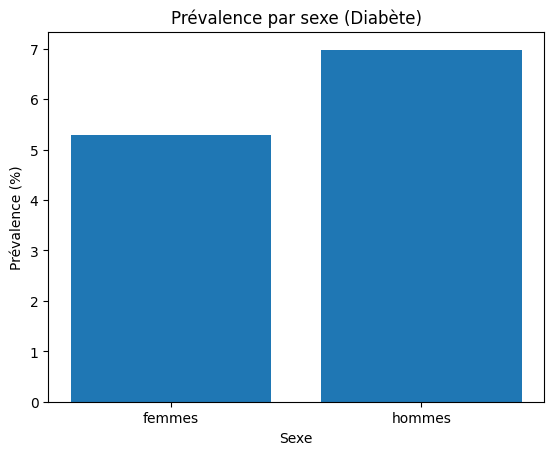

In [16]:
"""
Cela nous permet de faire un graphique comparatif, que l'on peut voir sur 
le Dashboard streamlit. On utilisera matplotlib pour l'affichage de graphique.
"""

import matplotlib.pyplot as plt

df_sexe = sp.stats_par_sexe(df, patho)

plt.figure()
plt.bar(df_sexe.index, df_sexe["prevalence_globale"])
plt.title(f"Prévalence par sexe ({patho})")
plt.xlabel("Sexe")
plt.ylabel("Prévalence (%)")
plt.show()

In [17]:
# Test des fonctions ratio_cas_hf et difference_prevalence_sexe

print("Ratio des cas H/F : ", sp.ratio_cas_hf(df, patho))
print("Différence de prévalence hommes - femmes : ", sp.difference_prevalence_sexe(df, patho))

Ratio des cas H/F :  1.213
Différence de prévalence hommes - femmes :  1.682


In [18]:
"""
Ensuite, nous pouvons développer des statistiques par tranche d'âge.
Les tranches d'âge sont triées dans l'ordre chronologique en appelant la 
fonction def ordre_tranche_age dans la class Conversion_donnees du script 
conversion.py présent dans utils
"""

print(sp.stats_par_tranche_age(df, patho))

                    Ntop_totale  Npop_totale  prevalence_globale
libelle_classe_age                                              
de 0 à 4 ans              14080     37967260               0.037
de 5 à 9 ans              86010     65611810               0.131
de 10 à 14 ans           179020     70335000               0.255
de 15 à 19 ans           250600     69128420               0.363
de 20 à 24 ans           302420     67012140               0.451
de 25 à 29 ans           422400     69358400               0.609
de 30 à 34 ans           643380     73050390               0.881
de 35 à 39 ans           978450     74144180               1.320
de 40 à 44 ans          1542160     74189810               2.079
de 45 à 49 ans          2602620     77287460               3.367
de 50 à 54 ans          4337270     78549240               5.522
de 55 à 59 ans          6547500     76162220               8.597
de 60 à 64 ans          8865350     71924600              12.326
de 65 à 69 ans         10

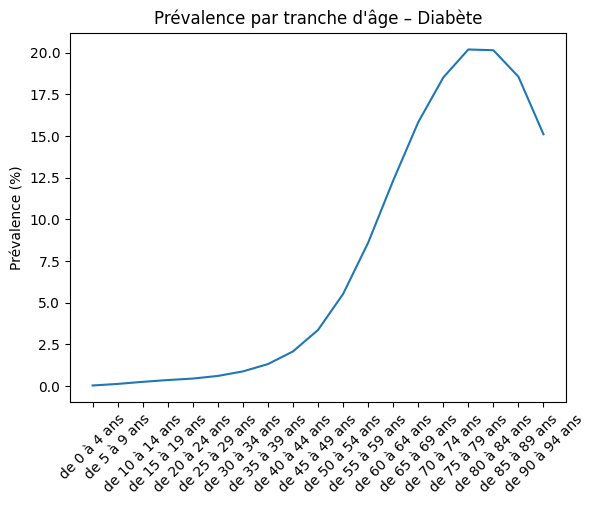

In [23]:
"""
Suite à ce dataframe, nous pouvons illustrer l'évolution d'une pathologie
en fonction de l'âge. Voici par exemple un graphique qui démontrer une 
évolution du diabète avec l'âge.
"""
df_age = sp.stats_par_tranche_age(df, patho)

plt.figure()
plt.plot(df_age.index, df_age["prevalence_globale"])
plt.xticks(rotation=45)
plt.title(f"Prévalence par tranche d'âge – {patho}")
plt.ylabel("Prévalence (%)")
plt.show()

In [27]:
"""
Possibilité de calculer l'écart de prévalence entre deux tranches d'âge 
avec la fonction difference_prevalence_age.
"""

tranche_1 = "de 60 à 64 ans"
tranche_2 = "de 80 à 84 ans"

print(f"L'écart de prévalence entre la tranche '{tranche_1}' et '{tranche_2} est de {sp.difference_prevalence_age(df, patho, tranche_1, tranche_2)}.")

L'écart de prévalence entre la tranche 'de 60 à 64 ans' et 'de 80 à 84 ans est de -7.814.


In [32]:
# Nous pouvons voir aussi l'âge central pour une pathologie

age_central = sp.age_central_pathologie(df, patho)
print(f"L'âge central de la pathologie '{patho}' est {age_central[0]}, avec une prévalence de {age_central[1]} %.")

L'âge central de la pathologie 'Diabète' est de 75 à 79 ans, avec une prévalence de 20.185 %.


### 4. Analyse temporelle

In [35]:
# Développons maintenant les statistiques par année (il y a 9 années étudiées).

df_annee = sp.stats_par_annee(df, patho)
print(df_annee)

       Ntop_totale  Npop_totale  prevalence_globale
annee                                              
2015      14179400    249334930               5.687
2016      14598580    253082340               5.768
2017      14951120    254295690               5.879
2018      15259300    256034850               5.960
2019      15648670    257430870               6.079
2020      16039110    257674180               6.225
2021      16549170    269089510               6.150
2022      16990070    271124480               6.267
2023      17410620    265217420               6.565


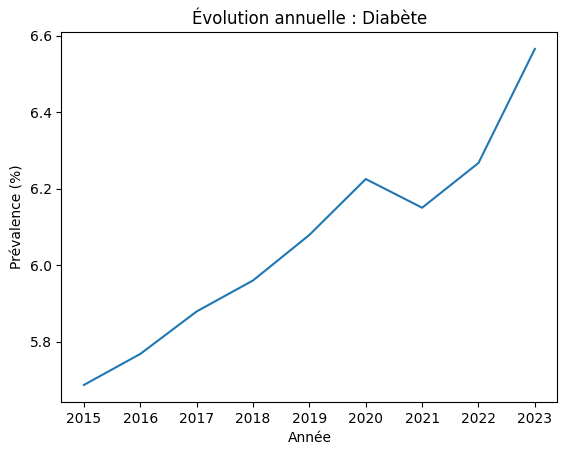

In [37]:
"""
Nous pouvons par exemple ici voir, pour la pathologie étudiée (Diabète) 
l'évolution annuelle de la prévalence grâce au graphique suivant.
"""

plt.figure()
plt.plot(df_annee.index, df_annee["prevalence_globale"])
plt.title(f"Évolution annuelle : {patho}")
plt.xlabel("Année")
plt.ylabel("Prévalence (%)")
plt.show()

In [38]:
# Calculons la variation annuelle de la prévalence pour une pathologie données
print(sp.variation_annuelle(df, patho))

{2016: {'difference absolue': 0.081, 'valeur relative': 1.424}, 2017: {'difference absolue': 0.111, 'valeur relative': 1.924}, 2018: {'difference absolue': 0.08, 'valeur relative': 1.361}, 2019: {'difference absolue': 0.119, 'valeur relative': 1.997}, 2020: {'difference absolue': 0.146, 'valeur relative': 2.402}, 2021: {'difference absolue': -0.075, 'valeur relative': -1.205}, 2022: {'difference absolue': 0.116, 'valeur relative': 1.886}, 2023: {'difference absolue': 0.298, 'valeur relative': 4.755}}


Cette fonction `def variation_annuelle(df, pathologie)`renvoie un dictionnaire avec les années à partir de la deuxième année étudiée jusqu'à la dernière.
Nous retrouvons par année deux valeurs :

- La différence absolue de la prévalence par rapport à l'année précédente. Méthode de calcul : **prev année n - prev année n-1**
- La valeur relative. Méthode de calcul : **(différence absolue calculée précédemment / prev année n-1) * 100**

Ce dictionnaire va permettre un affichage sur streamlit du dataframe et du graphique suivants.

In [40]:
# Affichage du DataFrame des variations annuelles
import pandas as pd

variation = sp.variation_annuelle(df, patho)
df_variation = pd.DataFrame(variation).T
df_variation.index.name = "Année"

print(df_variation)

       difference absolue  valeur relative
Année                                     
2016                0.081            1.424
2017                0.111            1.924
2018                0.080            1.361
2019                0.119            1.997
2020                0.146            2.402
2021               -0.075           -1.205
2022                0.116            1.886
2023                0.298            4.755


Figure(640x480)


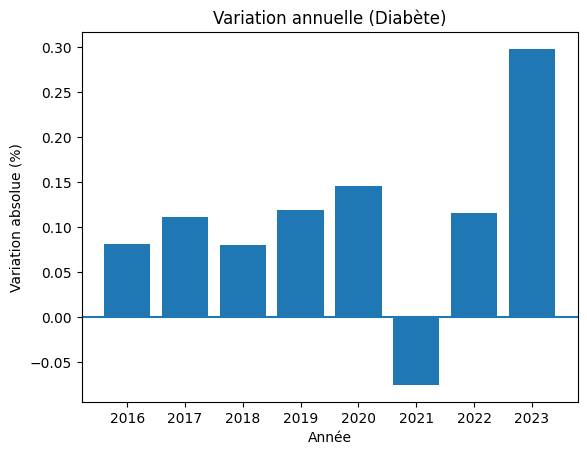

In [45]:
# Affichage du graphique de variation annuelle de la prévalence

fig, ax = plt.subplots()

ax.bar(
    df_variation.index,
    df_variation["difference absolue"]
)
ax.axhline(0)
ax.set_xlabel("Année")
ax.set_ylabel("Variation absolue (%)")
ax.set_title(f"Variation annuelle ({patho})")
print(fig)

In [47]:
"""
La tendance générale permet de déterminer une tendance de la prévalence 
globale d'une pathologie sur la période étudiée.

La tendance est calculée à partir de la moyenne des variations
annuelles absolues de prévalence :

- moyenne > 0  → "hausse"
- moyenne < 0  → "baisse"
- moyenne = 0  → "stable"

Si aucune variation ne peut être calculée (ex. une seule année
disponible ou données absentes), la fonction retourne None.
"""

tendance = sp.tendance_generale(df, patho)
print(f"Pendant la période étudiée, la prévalence de la pathologie {patho} est en {tendance}.")

Pendant la période étudiée, la prévalence de la pathologie Diabète est en hausse.


### 5. Analyse territoriale

L'analyse territoriale est intéressante car elle permet de distinguer les écarts de prévalence globale d'une pathologie en fonction du territoire.

Celle-ci est étudiée par département. On couvre d'ailleurs les 101 départements français, triés et traduits (code département -> nom département) via la `class Conversion_donnees présent` présent dans utils\conversion.py.

In [50]:
# Chargement des statistiques par département

df_dept = sp.stats_par_departement(df, patho)
df_dept.head(10)

,Ntop_totale,Npop_totale,prevalence_globale,departement_nom
dept,,,,
01,1159180,21378850,5.422,Ain
02,1422010,18160710,7.830,Aisne
03,913010,11523760,7.923,Allier
04,359730,5578460,6.449,Alpes-de-Haute-Provence
05,254300,4698430,5.412,Hautes-Alpes
06,2341990,39803140,5.884,Alpes-Maritimes
07,719460,11256550,6.391,Ardèche
08,717030,9103320,7.877,Ardennes
09,348320,5120610,6.802,Ariège


Nous pouvons ainsi voir les 10 départements les + touchés par le diabète avec la fonction `def top_departements` (nous l'afficherons ci-dessous). 

Nous pouvons aussi afficher les 10 départements les moins touchés avec `def bottom_departements`.

In [52]:
# Affichage des 10 départements les plus touchés par le diabète

print(sp.top_departements(df, patho))

   dept departement_nom  prevalence_globale
1   971      Guadeloupe              11.325
2   972      Martinique              10.392
3    58          Nièvre               9.403
4    23          Creuse               9.101
5   974      La Réunion               8.756
6    36           Indre               8.411
7    52     Haute-Marne               7.982
8    03          Allier               7.923
9    08        Ardennes               7.877
10   02           Aisne               7.830


In [54]:
"""
Nous avons aussi la possibilité de calculer la moyenne nationale de la 
prévalence pour une pathologie donnée. Cela nous permettra ensuite d'utiliser 
la fonction ecart_a_la_moyenne pour voir les département + ou - écartés de la 
moyenne.
"""

moy_nat = sp.moyenne_nationale(df, patho)
print(f"La moyenne nationale de la pathologie '{patho}' est : {moy_nat} %.")

La moyenne nationale de la pathologie 'Diabète' est : 6.07 %.


In [56]:
# Affichage de l'écart à la moyenne des premiers départements étudiés

print(sp.ecart_a_la_moyenne(df, patho))

       departement_nom  ecart_a_la_moyenne
dept                                      
35     Ille-et-Vilaine              -2.382
44    Loire-Atlantique              -1.801
74        Haute-Savoie              -1.669
75               Paris              -1.554
29           Finistère              -1.494
...                ...                 ...
974         La Réunion               2.686
23              Creuse               3.031
58              Nièvre               3.333
972         Martinique               4.322
971         Guadeloupe               5.255

[101 rows x 2 columns]


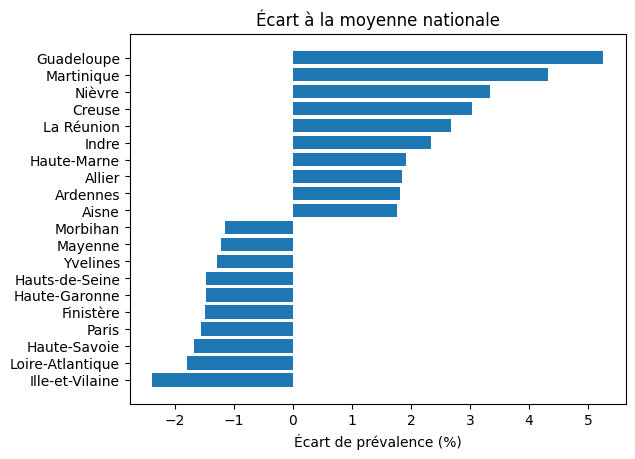

In [74]:
# Affichage graphique des 10 écarts à la moyenne les plus faibles et plus fortes
df_ecart = sp.ecart_a_la_moyenne(df, patho)
df_ecart = df_ecart.sort_values("ecart_a_la_moyenne")

df_selection = pd.concat([
    df_ecart.head(10),
    df_ecart.tail(10)])

plt.figure()
plt.barh(df_selection["departement_nom"], df_selection["ecart_a_la_moyenne"])
plt.title("Écart à la moyenne nationale")
plt.xlabel("Écart de prévalence (%)")
plt.show()

### 6. Détection d'anomalies